# How Wrong Is Your MMM?

Marketing Mix Models are only as reliable as the data they're trained on. When TV, Meta, and Search spend all move together — because they're driven by the same planning cycle — the model can't tell them apart. The result: elasticity estimates that swing wildly depending on which period of data you happened to use.

This notebook quantifies that problem using three channels (TV, Meta, Search) with known true elasticities, so we can measure exactly how far off the model is — and how much that depends on inter-channel correlation.

**Two sections:**
1. **Sweep correlation** — as inter-channel correlation increases, how unreliable do the estimates become?
2. **Fixed correlation, many seeds** — at a realistic correlation of 0.7, how different would your elasticity estimates be if you'd run the MMM in a slightly different period?

**Section 3** (run the diagnostic on your own spend data) follows in the next sprint.


In [1]:
# config
FAST_MODE = False   # set False for publication-quality runs (50 sims per level)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from how_wrong_is_your_mmm import CollinearityDiagnostic, simulate_spend, simulate_sales, fit_ols


## The setup

Three channels: **TV**, **Meta**, and **Search**. In a real business, all three budgets tend to move together — when demand forecasts rise, all go up; when they fall, all get cut. We model this with a latent demand signal that drives spend in all channels.

True elasticities: TV = 0.3, Meta = 0.5, Search = 0.4. We simulate sales as:

```
sales = base + 0.3 × TV + 0.5 × Meta + 0.4 × Search + noise
```

Then we fit OLS and ask: does it recover 0.3, 0.5, and 0.4? And how does the answer change as the channels become more correlated?


In [3]:
# single run at correlation 0.7 to show the setup
spend = simulate_spend(n_obs=104, correlation=0.7, seed=0)
print(f"Mean pairwise correlation: {spend.corr().to_numpy()[[0,0,1],[1,2,2]].mean():.2f}")
print()
for ch in spend.columns:
    print(f"{ch.upper():6s} spend range: £{spend[ch].min():,.0f} – £{spend[ch].max():,.0f}")


Mean pairwise correlation: 0.69

TV     spend range: £52,159 – £153,003
META   spend range: £34,352 – £133,152
SEARCH spend range: £21,938 – £95,538


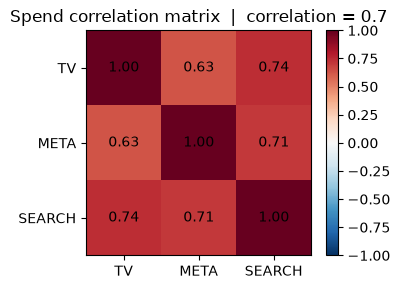

In [4]:
# show the correlation matrix
import matplotlib.pyplot as plt
import numpy as np

corr = spend.corr()
fig, ax = plt.subplots(figsize=(4, 3))
im = ax.imshow(corr.to_numpy(), vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels([c.upper() for c in corr.columns])
ax.set_yticklabels([c.upper() for c in corr.columns])
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=10)
plt.colorbar(im, ax=ax)
ax.set_title('Spend correlation matrix  |  correlation = 0.7')
plt.tight_layout()
plt.show()


## Section 1 — How bad does it get?

We run the same MMM across a range of correlation levels (0.1 → 0.9). At each level we simulate 50 different "periods" of data from the same market — same true elasticities, different noise draws. The spread of estimates across those 50 periods tells us how unreliable the model is at that correlation level.

A tight distribution means the model gives consistent answers. A wide distribution means the answer you get depends heavily on which period you happened to use — which is not a property you want in a model you're using to set budgets.


In [5]:
n_sims = 10 if FAST_MODE else 50
correlations = np.round(np.arange(0.1, 0.95, 0.1), 1).tolist()

results = []
for corr in correlations:
    diag = CollinearityDiagnostic(correlation=corr, spend_seed=0)
    diag.fit(n_sims=n_sims, fast_mode=FAST_MODE)
    df = diag.results_.copy()
    df['target_correlation'] = corr
    df['actual_correlation'] = round(diag.actual_correlation, 2)
    results.append(df)

all_results = pd.concat(results, ignore_index=True)
print(f'Total simulations: {len(all_results)}')
all_results.head()


Total simulations: 1350


,sim,channel,true_elasticity,estimated_elasticity,error,error_pct,target_correlation,actual_correlation
0,0,tv,0.3,0.353440,0.053440,17.813201,0.1,0.11
1,0,meta,0.5,0.638863,0.138863,27.772671,0.1,0.11
2,0,search,0.4,0.520667,0.120667,30.166760,0.1,0.11
3,1,tv,0.3,0.311812,0.011812,3.937479,0.1,0.11
4,1,meta,0.5,0.466568,-0.033432,-6.686338,0.1,0.11


In [6]:
summary_rows = []
for corr in correlations:
    sub = all_results[all_results['target_correlation'] == corr]
    for ch in ['tv', 'meta', 'search']:
        s = sub[sub['channel'] == ch]
        summary_rows.append({
            'target_corr': corr,
            'channel': ch,
            'true': s['true_elasticity'].iloc[0],
            'mean_est': s['estimated_elasticity'].mean(),
            'std_est': s['estimated_elasticity'].std(),
            'cv': s['estimated_elasticity'].std() / abs(s['estimated_elasticity'].mean()),
        })

sweep_summary = pd.DataFrame(summary_rows).round(3)
print(sweep_summary.to_string(index=False))


 target_corr channel  true  mean_est  std_est    cv
         0.1      tv   0.3     0.306    0.029 0.096
         0.1    meta   0.5     0.501    0.040 0.081
         0.1  search   0.4     0.391    0.055 0.140
         0.2      tv   0.3     0.309    0.044 0.142
         0.2    meta   0.5     0.501    0.058 0.116
         0.2  search   0.4     0.386    0.082 0.212
         0.3      tv   0.3     0.313    0.057 0.182
         0.3    meta   0.5     0.502    0.073 0.146
         0.3  search   0.4     0.382    0.106 0.276
         0.4      tv   0.3     0.316    0.069 0.219
         0.4    meta   0.5     0.502    0.087 0.174
         0.4  search   0.4     0.378    0.129 0.341
         0.5      tv   0.3     0.319    0.082 0.258
         0.5    meta   0.5     0.502    0.102 0.204
         0.5  search   0.4     0.372    0.154 0.413
         0.6      tv   0.3     0.323    0.098 0.302
         0.6    meta   0.5     0.502    0.120 0.240
         0.6  search   0.4     0.366    0.183 0.501
         0.7

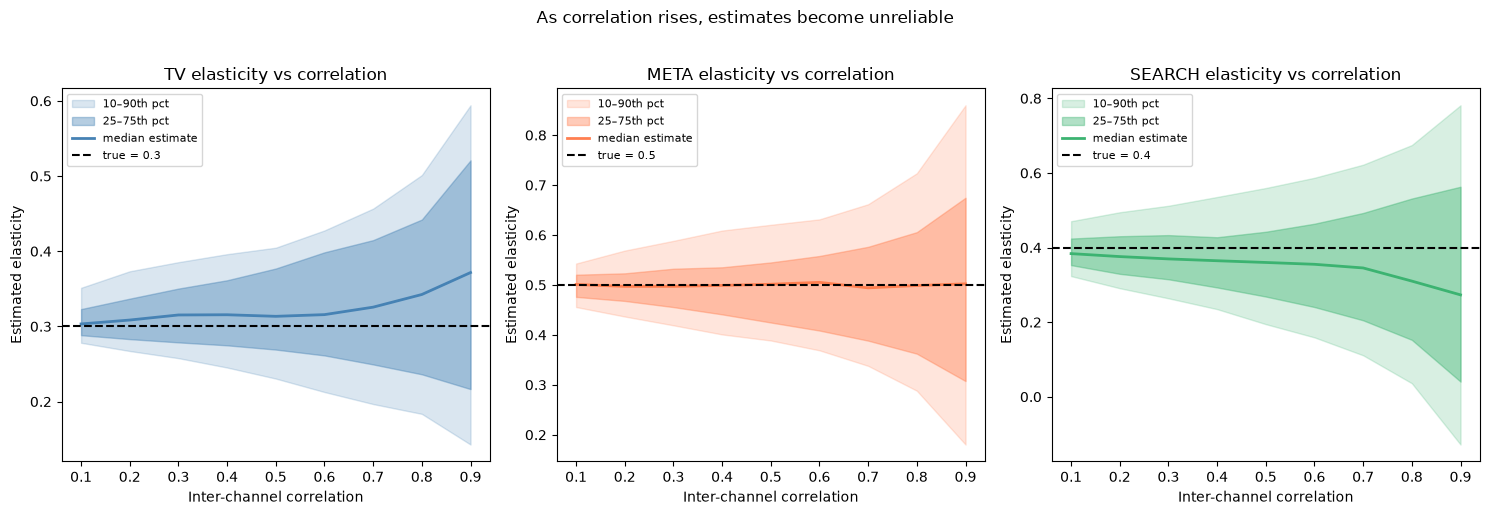

In [7]:
channels_cfg = [
    ('tv',     0.3, 'steelblue'),
    ('meta',   0.5, 'coral'),
    ('search', 0.4, 'mediumseagreen'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for ax, (channel, true_e, color) in zip(axes, channels_cfg):
    sub = all_results[all_results['channel'] == channel]

    medians = sub.groupby('target_correlation')['estimated_elasticity'].median()
    q25 = sub.groupby('target_correlation')['estimated_elasticity'].quantile(0.25)
    q75 = sub.groupby('target_correlation')['estimated_elasticity'].quantile(0.75)
    q10 = sub.groupby('target_correlation')['estimated_elasticity'].quantile(0.10)
    q90 = sub.groupby('target_correlation')['estimated_elasticity'].quantile(0.90)

    ax.fill_between(correlations, q10, q90, alpha=0.2, color=color, label='10–90th pct')
    ax.fill_between(correlations, q25, q75, alpha=0.4, color=color, label='25–75th pct')
    ax.plot(correlations, medians, color=color, linewidth=2, label='median estimate')
    ax.axhline(true_e, color='black', linestyle='--', linewidth=1.5, label=f'true = {true_e}')

    ax.set_xlabel('Inter-channel correlation')
    ax.set_ylabel('Estimated elasticity')
    ax.set_title(f'{channel.upper()} elasticity vs correlation')
    ax.legend(fontsize=8)

plt.suptitle('As correlation rises, estimates become unreliable', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


**What this shows:** the median estimate stays close to the true value — OLS is unbiased. But the spread explodes as correlation increases. At correlation 0.9, the interquartile range is so wide that you could easily get an estimate that's double or half the true value, purely by chance.

This is the core problem: collinearity doesn't make the average wrong. It makes the answer unreliable. The model could tell you TV is your best channel, or your worst, depending on the data vintage — and both answers come from the same model on the same market.


## Section 2 — Your model could have said anything

Now we fix correlation at 0.7 — typical for two channels following the same campaign calendar — and run 50 different noise seeds. Each seed is a plausible alternative history: the same market, the same true elasticities, but a slightly different period of data.

How different are the estimated elasticities? This is the question every practitioner should ask before trusting an MMM output.


In [8]:
diag_fixed = CollinearityDiagnostic(correlation=0.7, spend_seed=0)
diag_fixed.fit(n_sims=n_sims, fast_mode=FAST_MODE)

print(f'Mean pairwise correlation: {diag_fixed.actual_correlation:.2f}')
print()
print(diag_fixed.summary().to_string(index=False))


Mean pairwise correlation: 0.69

channel  true_elasticity  mean_estimated  std_estimated  mean_error_pct  coef_of_variation
   meta              0.5          0.5026         0.1449          0.5247             0.2884
 search              0.4          0.3573         0.2225        -10.6771             0.6228
     tv              0.3          0.3291         0.1173          9.6867             0.3565


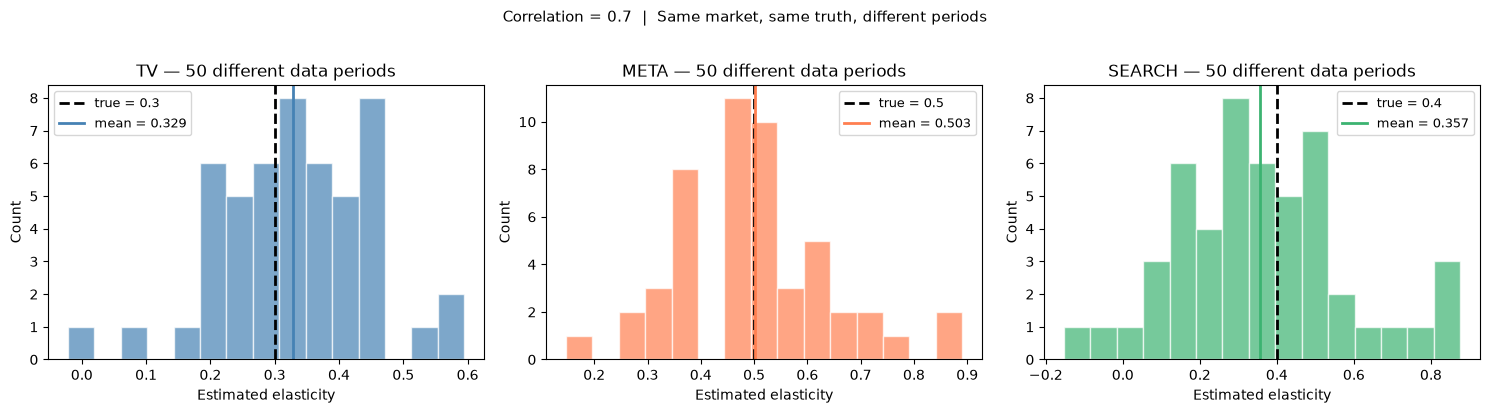

In [9]:
channels_cfg = [
    ('tv',     0.3, 'steelblue'),
    ('meta',   0.5, 'coral'),
    ('search', 0.4, 'mediumseagreen'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (channel, true_e, color) in zip(axes, channels_cfg):
    estimates = diag_fixed.results_[
        diag_fixed.results_['channel'] == channel
    ]['estimated_elasticity']

    ax.hist(estimates, bins=15, color=color, alpha=0.7, edgecolor='white')
    ax.axvline(true_e, color='black', linestyle='--', linewidth=2, label=f'true = {true_e}')
    ax.axvline(estimates.mean(), color=color, linestyle='-', linewidth=2,
               label=f'mean = {estimates.mean():.3f}')

    ax.set_xlabel('Estimated elasticity')
    ax.set_ylabel('Count')
    ax.set_title(f'{channel.upper()} — {n_sims} different data periods')
    ax.legend(fontsize=9)

plt.suptitle('Correlation = 0.7  |  Same market, same truth, different periods',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()


In [10]:
true_elasticities = {'tv': 0.3, 'meta': 0.5, 'search': 0.4}
for channel, true_e in true_elasticities.items():
    estimates = diag_fixed.results_[
        diag_fixed.results_['channel'] == channel
    ]['estimated_elasticity']
    lo, hi = estimates.quantile(0.1), estimates.quantile(0.9)
    print(f'{channel.upper():6s}  true={true_e:.1f}  80% range: [{lo:.3f}, {hi:.3f}]  width={hi-lo:.3f}')


TV      true=0.3  80% range: [0.197, 0.457]  width=0.260
META    true=0.5  80% range: [0.338, 0.662]  width=0.324
SEARCH  true=0.4  80% range: [0.111, 0.622]  width=0.511


**What this means in practice:** at correlation 0.7, your TV elasticity estimate has an 80% range that spans that entire interval. Refit the model next quarter with three more months of data and you'll likely get a different number — not because the market changed, but because the data was never informative enough to pin it down.

This is why MMM outputs shift every time you refit. It's not the model, and it's not the analyst. It's the data design.

**The fix:** deliberately vary the budget mix — more TV in some periods, more Meta in others. That de-correlates the channels and gives the model the variation it needs to tell them apart. That's the budget perturbation recommendation (next sprint).


## Section 3 — Your spend data

The diagnostic above uses synthetic spend. But the most useful version is personalised: run the same simulation on *your* actual channel spend, with *your* actual correlation structure.

When you pass your own spend DataFrame, we skip the synthetic spend generation entirely. We only simulate the sales column — applying known elasticities to your real spend and adding noise. The collinearity in your data is already there; we're just quantifying how much it matters.

Below we demonstrate with a synthetic spend DataFrame passed in as if it were real. Swap it for your own data and the rest is identical.


In [11]:
# simulate a 'real' spend DataFrame — swap this for your actual data
real_spend = simulate_spend(n_obs=104, correlation=0.65, seed=7)
print(f'Spend DataFrame: {real_spend.shape[0]} weeks, channels: {list(real_spend.columns)}')
print(f'Mean pairwise correlation: {real_spend.corr().to_numpy()[[0,0,1],[1,2,2]].mean():.2f}')


Spend DataFrame: 104 weeks, channels: ['tv', 'meta', 'search']
Mean pairwise correlation: 0.65


In [12]:
# run the diagnostic on real spend
diag_real = CollinearityDiagnostic(
    spend_df=real_spend,
    true_elasticities={'tv': 0.3, 'meta': 0.5, 'search': 0.4},
)
diag_real.fit(n_sims=n_sims, fast_mode=FAST_MODE)

print(f'Mean pairwise correlation in your spend: {diag_real.actual_correlation:.2f}')
print()
print(diag_real.summary().to_string(index=False))


Mean pairwise correlation in your spend: 0.65

channel  true_elasticity  mean_estimated  std_estimated  mean_error_pct  coef_of_variation
   meta              0.5          0.4955         0.1475         -0.8911             0.2976
 search              0.4          0.4526         0.2173         13.1619             0.4802
     tv              0.3          0.3025         0.1303          0.8470             0.4307


In [13]:
for channel, true_e in {'tv': 0.3, 'meta': 0.5, 'search': 0.4}.items():
    estimates = diag_real.results_[
        diag_real.results_['channel'] == channel
    ]['estimated_elasticity']
    lo, hi = estimates.quantile(0.1), estimates.quantile(0.9)
    print(f'{channel.upper():6s}  true={true_e:.1f}  80% range: [{lo:.3f}, {hi:.3f}]  width={hi-lo:.3f}')


TV      true=0.3  80% range: [0.130, 0.463]  width=0.333
META    true=0.5  80% range: [0.311, 0.653]  width=0.342
SEARCH  true=0.4  80% range: [0.188, 0.769]  width=0.581


The 80% range above is your personalised answer to *how wrong is your MMM*. It's not a generic warning about collinearity — it's a quantification of the unreliability in your specific spend data, given your specific correlation structure.

A narrower range means your channels are sufficiently de-correlated and your elasticity estimates are stable. A wide range means the budget mix hasn't varied enough to let the model distinguish individual channel effects — and the budget perturbation recommendation (next sprint) will show you what to do about it.
